# Expressivity on IBM Quantum Hardware — IBM Aachen

This notebook measures the **Order Statistics Score (ORS/\(\Lambda\))** and runs **QELM** on circuits executed directly on IBM Aachen via Qiskit Runtime.

## Part 1 — Infrastructure

The first two code blocks define all hardware utility functions:
- **`qubit_error_scores()`** — reads per-qubit readout errors and per-edge two-qubit gate errors from the backend calibration snapshot.
- **`coupling_adjacency()`** — converts the backend coupling map to an adjacency dict.
- **`grow_block()`** — greedy BFS to find a low-error connected subgraph of `size` qubits.
- **`find_disjoint_blocks()`** — calls `grow_block()` repeatedly to find multiple disjoint blocks separated by a qubit buffer, enabling parallel independent experiments on one chip.
- **`split_counts_per_block()`** — parses Qiskit's multi-register bitstring counts back into per-block dicts.

In [1]:
import math
import numpy as np
from collections import defaultdict

from qiskit import QuantumCircuit, ClassicalRegister
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel
from qiskit_ibm_runtime.fake_provider import FakeAachen

# ============================================================
# 2. Qubit layout: find disjoint n-qubit connected subgraphs
# ============================================================
def qubit_error_scores(backend):
    """
    Return:
      readout_err[q] : float
      edge_err[(a,b)] : float  (symmetric, lower = better)
    """
    props = backend.properties()
    readout_err = {}
    for q in range(backend.num_qubits):
        try:
            readout_err[q] = props.readout_error(q)
        except Exception:
            readout_err[q] = 0.05  # fallback

    # 2Q gate errors: look for ecr / cz / cx (Heron uses cz; older devices ecr/cx)
    edge_err = {}
    for gate in props.gates:
        if gate.gate in ("cz", "ecr", "cx") and len(gate.qubits) == 2:
            err = None
            for p in gate.parameters:
                if p.name == "gate_error":
                    err = p.value
                    break
            if err is None:
                continue
            a, b = gate.qubits
            edge_err[(a, b)] = err
            edge_err[(b, a)] = err
    return readout_err, edge_err


def coupling_adjacency(backend):
    """Undirected adjacency dict from the coupling map."""
    adj = defaultdict(set)
    for a, b in backend.coupling_map.get_edges():
        adj[a].add(b)
        adj[b].add(a)
    return adj


def grow_block(seed, adj, used, size, edge_err):
    """
    Greedy BFS from `seed`: at each step add the neighbor (of the current block)
    with the lowest gate error to any block member. Returns block of `size`
    qubits or None if not possible.
    """
    if seed in used:
        return None
    block = {seed}
    frontier = set(n for n in adj[seed] if n not in used)

    while len(block) < size:
        if not frontier:
            return None
        # pick frontier qubit with min edge_err to any block member
        best_q, best_err = None, math.inf
        for q in frontier:
            local = min(
                (edge_err.get((q, b), math.inf) for b in block if b in adj[q]),
                default=math.inf,
            )
            if local < best_err:
                best_err, best_q = local, q
        if best_q is None or best_err == math.inf:
            return None
        block.add(best_q)
        frontier.discard(best_q)
        for nb in adj[best_q]:
            if nb not in used and nb not in block:
                frontier.add(nb)
    return block


def score_block(block, adj, edge_err, readout_err):
    """Sum of intra-block edge errors + readout errors. Lower is better."""
    s = sum(readout_err[q] for q in block)
    seen = set()
    for q in block:
        for nb in adj[q]:
            if nb in block and (nb, q) not in seen:
                s += edge_err.get((q, nb), 1.0)
                seen.add((q, nb))
    return s


def find_disjoint_blocks(backend, n_qubits=16, max_blocks=10, buffer=1):
    """
    Greedily find disjoint connected n_qubits-size blocks separated by `buffer`
    unused qubits (buffer=1 means the immediate neighbors of any chosen qubit
    are forbidden from other blocks).
    """
    readout_err, edge_err = qubit_error_scores(backend)
    adj = coupling_adjacency(backend)
    all_qubits = list(range(backend.num_qubits))
    # seed order: lowest-readout-error qubits first
    seeds = sorted(all_qubits, key=lambda q: readout_err[q])

    used = set()
    blocks = []

    for seed in seeds:
        if len(blocks) >= max_blocks:
            break
        if seed in used:
            continue
        block = grow_block(seed, adj, used, n_qubits, edge_err)
        if block is None:
            continue
        # mark block + buffer ring as used
        used |= block
        if buffer > 0:
            ring = set()
            frontier = set(block)
            for _ in range(buffer):
                new_frontier = set()
                for q in frontier:
                    for nb in adj[q]:
                        if nb not in block and nb not in ring:
                            ring.add(nb)
                            new_frontier.add(nb)
                frontier = new_frontier
            used |= ring
        blocks.append(sorted(block))

    # Print summary
    for i, blk in enumerate(blocks):
        s = score_block(blk, adj, edge_err, readout_err)
        print(f"  Block {i}: {blk}  (score={s:.4f})")
    return blocks

def split_counts_per_block(counts, blocks):
    """
    Qiskit count keys are written with whitespace separating classical registers,
    in REGISTER-REVERSED order: 'c{N-1} c{N-2} ... c0'. Each register's bits
    are also little-endian within itself. We just split on whitespace and use
    the natural ordering of each substring.
    Returns list of dicts {bitstring -> count} per block.
    """
    per_block = [defaultdict(int) for _ in blocks]
    for key, n in counts.items():
        parts = key.split()  # length = len(blocks), reversed register order
        # parts[0] is the LAST added register, parts[-1] is the first
        parts = list(reversed(parts))
        for i, bits in enumerate(parts):
            per_block[i][bits] += n
    return per_block

## Part 2 — Count-Space ORS Functions

Standard ORS operates on **probability vectors** (exact from statevectors). On hardware, we only have measurement **counts** from \(S\) shots. This block defines the count-space equivalent:

- **`log_likelihood_counts(counts, S, f, D, K_star)`** — evaluates the noisy Haar log-likelihood at the top-K observed counts (Eq. 8 of the project plan). This is ORS in count space.
- **`estimate_fidelity_from_counts()`** — maximum-likelihood estimate of the depolarising fidelity \(f\) from measured counts.
- **`lambda_score_counts()`** — count-space ORS score at fixed \(f\): higher = more Haar-like.
- **`analytical_haar_reference(N, S, f, K)`** — analytical mean and std of \(\ln\Lambda\) under noisy Haar, used as the reference baseline for count-space gap plots.

In [65]:
import math
import numpy as np
from collections import defaultdict

from qiskit import QuantumCircuit
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.transpiler import CouplingMap
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_aer import AerSimulator
from qiskit_aer.noise import (
    NoiseModel, depolarizing_error, thermal_relaxation_error, ReadoutError,
)
from scipy.special import digamma
from metrics import lorentz_curves_noisy, order_statistics_score_noisy, lambda_haar_largeD_noisy


####################################
# Fixed-noise Haar measure
####################################
# ============================================================
# 2. LOCAL noise model for one block
# ============================================================
def build_local_noise_model(backend, block):
    """
    Build a NoiseModel covering only the qubits in `block`, with those qubits
    relabeled to 0..len(block)-1 so it applies to a small 16-qubit simulator.

    Includes:
      - 1Q gate depolarizing error (per qubit, per gate in basis)
      - 2Q gate depolarizing error (per edge, for cz/ecr/cx)
      - Readout error (per qubit)
      - Thermal relaxation from T1/T2 and gate duration
    """
    props = backend.properties()
    qmap = {phys: log for log, phys in enumerate(block)}  # phys -> logical
    block_set = set(block)

    nm = NoiseModel()

    # ---- 1Q gates ----
    one_q_gates = ("sx", "x", "rz", "id")
    for phys in block:
        log = qmap[phys]
        try:
            T1 = props.t1(phys)
            T2 = props.t2(phys)
        except Exception:
            T1, T2 = 100e-6, 100e-6
        for gname in one_q_gates:
            try:
                gerr = props.gate_error(gname, [phys])
                gtime = props.gate_length(gname, [phys])
            except Exception:
                continue
            # Combine depolarizing + thermal relaxation
            depol = depolarizing_error(max(gerr, 0.0), 1)
            thermal = thermal_relaxation_error(T1, min(T2, 2 * T1), gtime)
            err = thermal.compose(depol)
            nm.add_quantum_error(err, gname, [log])

    # ---- 2Q gates (cz / ecr / cx) ----
    for g in props.gates:
        if g.gate not in ("cz", "ecr", "cx") or len(g.qubits) != 2:
            continue
        a, b = g.qubits
        if a not in block_set or b not in block_set:
            continue
        gerr = next((p.value for p in g.parameters if p.name == "gate_error"), None)
        gtime = next((p.value for p in g.parameters if p.name == "gate_length"), None)
        if gerr is None: continue
        la, lb = qmap[a], qmap[b]
        depol = depolarizing_error(max(gerr, 0.0), 2)
        if gtime is not None:
            try:
                T1a, T2a = props.t1(a), props.t2(a)
                T1b, T2b = props.t1(b), props.t2(b)
                thermal = thermal_relaxation_error(T1a, min(T2a, 2*T1a), gtime).expand(
                          thermal_relaxation_error(T1b, min(T2b, 2*T1b), gtime))
                err = thermal.compose(depol)
            except Exception:
                err = depol
        else:
            err = depol
        nm.add_quantum_error(err, g.gate, [la, lb])

    # ---- Readout ----
    for phys in block:
        log = qmap[phys]
        try:
            p_meas0_prep1 = props.qubit_property(phys, "prob_meas0_prep1")[0]
            p_meas1_prep0 = props.qubit_property(phys, "prob_meas1_prep0")[0]
        except Exception:
            # Fallback: symmetric readout error
            p = props.readout_error(phys)
            p_meas0_prep1 = p_meas1_prep0 = p
        ro = ReadoutError([[1 - p_meas1_prep0, p_meas1_prep0],
                           [p_meas0_prep1, 1 - p_meas0_prep1]])
        nm.add_readout_error(ro, [log])

    return nm


def build_local_coupling(backend, block):
    """CouplingMap among the block qubits, relabeled to 0..n-1."""
    qmap = {phys: log for log, phys in enumerate(block)}
    block_set = set(block)
    edges = []
    for a, b in backend.coupling_map.get_edges():
        if a in block_set and b in block_set:
            edges.append([qmap[a], qmap[b]])
    return CouplingMap(edges)


def haar_mean_pk(k_array, D):
    """
    <p_k>_Haar = (1/D) * [psi(D+1) - psi(k)]
    From Fig. 2 caption of Micklitz 2025.
    """
    k_array = np.asarray(k_array, dtype=float)
    return (digamma(D + 1) - digamma(k_array)) / D
 
 
def noisy_pk(f, k_array, D):
    """
    p_k(f) = f * <p_k>_Haar + (1-f)/D    (Eq. 3)
    """
    return f * haar_mean_pk(k_array, D) + (1.0 - f) / D
 
 
def log_likelihood_counts(counts_array, S, f, D, K_star=None):
    """
    Count-based log-likelihood (Eq. 8).
 
    Args:
        counts_array: array of shape (K,) with the top-K raw counts n_1, ..., n_K
                      (n_1 is the largest count, n_2 second largest, etc.)
                      MUST be raw integer counts, not normalized probabilities.
        S: total number of shots used to obtain those counts.
        f: fidelity (scalar in (0, 1]).
        D: Hilbert space dimension (= 2^N).
        K_star: indices of ranks to include. Default: all of 1..K.
                Paper uses ranks deep in the Gumbel tail (k ~ O(N)).
 
    Returns:
        ln Lambda(f) -- scalar. f-independent constants are omitted (as in paper).
    """
    counts_array = np.asarray(counts_array, dtype=float)
    K = len(counts_array)
    if K_star is None:
        K_star = np.arange(1, K + 1)
    else:
        K_star = np.asarray(K_star, dtype=int)
 
    # Index into counts_array (which is 0-indexed) using k-1
    n_k = counts_array[K_star - 1]
    pk_f = noisy_pk(f, K_star, D)
 
    # Eq. 8: sum_k (n_k * ln p_k(f) - S * p_k(f))
    return np.sum(n_k * np.log(pk_f) - S * pk_f)
 
 
def estimate_fidelity_from_counts(counts_array, S, D, K_star=None,
                                  f_grid=None):
    """
    MLE: find f that maximizes Eq. 8.
 
    Returns:
        f_hat: estimated fidelity
        ll_curve: (f_grid, ln_Lambda values) for plotting/inspection
    """
    if f_grid is None:
        f_grid = np.linspace(0.01, 1.0, 200)
 
    ll = np.array([log_likelihood_counts(counts_array, S, f, D, K_star)
                   for f in f_grid])
    f_hat = f_grid[np.argmax(ll)]
    return f_hat, (f_grid, ll)
 
 
def lambda_score_counts(counts_array, S, f, D, K_star=None):
    """
    Use Eq. 8 as a SCORE (not a fidelity estimator) at fixed f.
 
    This is the analogue of order_statistics_score_noisy in count space:
    given a hypothesized f (e.g., from gate-count estimation), return the
    log-likelihood that the observed counts came from a Haar ensemble with
    that depolarizing fidelity. Higher = more Haar-like.
 
    To compare two reservoir families (G1 vs G3) at fixed f and shot count,
    just compute this per instance and average. The family with higher mean
    score is closer to noisy-Haar.
    """
    return log_likelihood_counts(counts_array, S, f, D, K_star)

# ============================================================
# How to get counts_array from a Qiskit counts dict
# ============================================================
def top_K_counts_from_dict(counts_dict, K):
    """
    Extract the top-K counts from a Qiskit `result.get_counts()` dict.
 
    Returns an array of length K with the K largest counts in descending order.
    If fewer than K distinct bitstrings were observed, pads with zeros.
    """
    values = sorted(counts_dict.values(), reverse=True)
    arr = np.zeros(K, dtype=float)
    arr[:min(K, len(values))] = values[:K]
    return arr

from scipy.special import digamma


def haar_mean_single_pk(K, D):
    """Haar order-statistic mean: <p_k>_Haar = (1/D)[psi(D+1) - psi(k)]"""
    k = np.arange(1, K + 1)
    return (digamma(D + 1) - digamma(k)) / D


def noisy_haar_pk(K, D, f):
    """Noisy order-statistic mean: p_k(f) = f * <p_k>_Haar + (1-f)/D"""
    return f * haar_mean_single_pk(K, D) + (1.0 - f) / D


def analytical_haar_reference(N, S, f, K):
    """
    Analytical mean and std of ln Lambda(f) under noisy Haar (Eq. 8).

    Returns:
        mean: E[ln Lambda]_Haar
        std:  sqrt(Var[ln Lambda]_Haar)
    """
    D = 2 ** N
    pk = noisy_haar_pk(K, D, f)
    log_pk = np.log(pk)

    mean = S * np.sum(pk * (log_pk - 1.0))
    var = S * np.sum(pk * log_pk ** 2)
    return mean, np.sqrt(var)

## Part 3 — Circuit Construction Example

We build circuits for each (family, gate-count) combination using `build_parallel_circuit()`, which places identical circuits on each disjoint qubit block and adds separate classical registers for parallel measurement.

Families tested:
- **G1** — Clifford gate set {CNOT, H, S}: low expressivity reference.
- **G3** — non-Clifford gate set {CNOT, H, T}: expected near Haar.
- **D2_random / D2_random_XZ / D2_random_XZY** — IQP-style commuting-diagonal circuits.

Each circuit is transpiled to IBM Aachen's native gate set ({rz, sx, x, cz}) at optimisation level 3 before submission.

In [66]:
from metrics import build_parallel_circuit

backend = FakeAachen()
blocks = find_disjoint_blocks(backend, n_qubits=12, max_blocks=5, buffer=2)

for name, kwargs in [
    ("G1",            {'depth': 80}),
    ("G3",            {'depth': 80}),
    ("D2_random",     {"expected_degree": 3}),
    ("D2_random_XZ",  {"expected_degree": 3, "n_layers": 1}),
    ("D2_random_XZY", {"expected_degree": 3, "n_layers": 1}),
]:
    qc, _ = build_parallel_circuit(backend, blocks, name, seed=0, **kwargs)
    pm = generate_preset_pass_manager(optimization_level=3, backend=backend)
    isa = pm.run(qc)
    print(f"\n{name:25s}  original: depth={qc.depth():4d}  ops={dict(qc.count_ops())}")
    print(f"{name:25s}  transpilled: depth={isa.depth():4d}  ops={dict(isa.count_ops())}")

  Block 0: [3, 4, 5, 7, 16, 17, 23, 24, 25, 26, 27, 28]  (score=0.0670)
  Block 1: [11, 12, 13, 14, 15, 18, 31, 32, 33, 34, 39, 53]  (score=0.0896)
  Block 2: [80, 81, 82, 83, 96, 100, 101, 102, 103, 116, 120, 121]  (score=0.1453)
  Block 3: [36, 40, 41, 42, 43, 44, 56, 63, 64, 65, 66, 77]  (score=0.1092)
  Block 4: [90, 91, 98, 110, 111, 112, 113, 114, 115, 119, 132, 133]  (score=0.1127)

G1                         original: depth= 205  ops={'cx': 1609, 'x': 1605, 'h': 1586, 'measure': 60}
G1                         transpilled: depth= 223  ops={'sx': 1024, 'rz': 937, 'cz': 788, 'x': 165, 'measure': 60}

G3                         original: depth= 205  ops={'cx': 1609, 't': 1605, 'h': 1586, 'measure': 60}
G3                         transpilled: depth= 256  ops={'sx': 1629, 'rz': 1592, 'cz': 902, 'x': 102, 'measure': 60}

D2_random                  original: depth=   6  ops={'h': 120, 'rz': 60, 'measure': 60, 'rzz': 13}
D2_random                  transpilled: depth=  21  ops={'rz': 220

In [67]:
n_qubits = 12
depth  = 10
buffer = 2
max_blocks = 5
shots=20000
family = 'G3'

## Transpile and Inspect Circuits

Circuits are built in parallel across all disjoint qubit blocks and transpiled to the native IBM gate set. The transpiled depth and gate count give an upper bound on the error budget used in fidelity estimation.

In [68]:
from metrics import build_parallel_circuit

backend = FakeAachen()
blocks = find_disjoint_blocks(backend, n_qubits=12, max_blocks=5, buffer=2)
qc, _ = build_parallel_circuit(backend, blocks, family, seed=0, depth=depth)
print(f"\n{family:5s}:  depth={qc.depth():4d}  ops={dict(qc.count_ops())}, total_ops = {np.sum(list(dict(qc.count_ops()).values())[:-1])}")

  Block 0: [3, 4, 5, 7, 16, 17, 23, 24, 25, 26, 27, 28]  (score=0.0670)
  Block 1: [11, 12, 13, 14, 15, 18, 31, 32, 33, 34, 39, 53]  (score=0.0896)
  Block 2: [80, 81, 82, 83, 96, 100, 101, 102, 103, 116, 120, 121]  (score=0.1453)
  Block 3: [36, 40, 41, 42, 43, 44, 56, 63, 64, 65, 66, 77]  (score=0.1092)
  Block 4: [90, 91, 98, 110, 111, 112, 113, 114, 115, 119, 132, 133]  (score=0.1127)

G3   :  depth=  31  ops={'cx': 208, 'h': 201, 't': 191, 'measure': 60}, total_ops = 600


## Submitting to Real Hardware (commented out)

This cell shows the full Qiskit Runtime workflow for submitting circuits to a real IBM device:
1. Load the backend via `QiskitRuntimeService`.
2. Transpile circuits to the native ISA using `generate_preset_pass_manager`.
3. Submit via `SamplerV2` and wait for results.
4. Extract per-block counts using `split_counts_per_block()`.

The code is commented out to avoid accidental hardware submission; results used in the analysis below are pre-loaded from `results/hardware_runs/ORS/`.

In [69]:
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

# 1. Load backend
#service = QiskitRuntimeService()
#backend = service.backend('ibm_kingston')

# Enable basic error mitigation (dynamic decoupling helps for idle qubits)
#sampler.options.dynamical_decoupling.enable = True
#sampler.options.dynamical_decoupling.sequence_type = "XY4"

# Pauli Twirling (converts coherent noise into approximately depolarizing noise)
#sampler.options.twirling.enable_gates = True
#sampler.options.twirling.enable_measure = True
#sampler.options.twirling.num_randomizations = "auto"

# 2. Transpile to ISA of the backend
#pm = generate_preset_pass_manager(optimization_level=1, backend=backend)
#isa_qc = pm.run(qc)

# 3. Submit via Sampler primitive
#sampler = Sampler(mode=backend)
#job = sampler.run([isa_qc], shots=shots)
#print(f"Job ID: {job.job_id()}")    
#print(f"Job status: {job.status()}")

# 4. Get the result (blocks until job completes — could be minutes to hours)
#result = job.result()

# 5. Extract per-block counts
#    SamplerV2 returns a structured result: result[0].data has one attribute
#    per ClassicalRegister, each with a .get_counts() method.
#pub_result = result[0]
#per_block_counts = []
#for i, blk in enumerate(blocks):
#    cr_name = f"c{i}"   # matches the register name from build_parallel_circuit
#    bit_array = getattr(pub_result.data, cr_name)
#    counts_dict = bit_array.get_counts()
#    per_block_counts.append(counts_dict)

## Fidelity Estimation from Gate-Error Budget

`estimate_fidelity_per_block(qc_transpiled, backend, block)` estimates the effective depolarising fidelity \(f\) for one qubit block by summing the gate errors and readout errors of all operations acting on that block:

$$f = \exp\!\left(-\sum_{\text{gates}} \epsilon_g - \sum_{q \in \text{block}} \epsilon_q^{\text{ro}}\right).$$

This gives a per-block scalar \(f \in (0,1]\) that feeds directly into the noisy Haar baseline \(\Lambda^{\mathrm{Haar},\mathrm{noisy}}(f)\) and the count-space reference \(\langle\Lambda\rangle_{\mathrm{Haar}}(f)\).

In [70]:
def estimate_fidelity_per_block(qc_transpiled, backend, block):
    """
    Estimate fidelity for ONE block: sum errors only for gates and measurements
    that act on qubits in this physical block.
    """
    props = backend.properties()
    block_set = set(block)
    
    total_gate_err = 0.0
    total_readout_err = 0.0
    breakdown = {"1q": 0.0, "2q": 0.0, "readout": 0.0, "counts": {}}
    
    for instr in qc_transpiled.data:
        op_name = instr.operation.name
        if op_name in ("measure", "barrier", "delay"):
            continue
        phys_q = [qc_transpiled.find_bit(q).index for q in instr.qubits]
        
        # Skip if this gate doesn't act on our block
        if not all(q in block_set for q in phys_q):
            continue
        
        err = None
        try:
            err = props.gate_error(op_name, phys_q)
        except Exception:
            pass
        if err is None and len(phys_q) == 2:
            try:
                err = props.gate_error(op_name, phys_q[::-1])
            except Exception:
                pass
        if err is None:
            err = 0.0 if op_name == "rz" else 0.0
        
        total_gate_err += err
        if len(phys_q) == 1:
            breakdown["1q"] += err
        else:
            breakdown["2q"] += err
        breakdown["counts"][op_name] = breakdown["counts"].get(op_name, 0) + 1
    
    # Readout only for this block's qubits
    for phys in block:
        try:
            total_readout_err += props.readout_error(phys)
        except Exception:
            pass
    breakdown["readout"] = total_readout_err
    
    f = math.exp(-(total_gate_err + total_readout_err))
    return f, breakdown


from qiskit_ibm_runtime.fake_provider import FakeAachen
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

backend = FakeAachen()
block = blocks[4]
# Transpile your circuit (the same one your student ran on real ibm_aachen)
pm = generate_preset_pass_manager(optimization_level=1, backend=backend)
isa_qc = pm.run(qc)

# Estimate f from the snapshot properties
f_gate, brk = estimate_fidelity_per_block(isa_qc, backend, block)
print(f"Gate-budget f: {f_gate:.3f}")
print(f"  1q error:     {brk['1q']:.4f}")
print(f"  2q error:     {brk['2q']:.4f}")
print(f"  readout err:  {brk['readout']:.4f}")
print(f"  gate counts:  {brk['counts']}")


Gate-budget f: 0.863
  1q error:     0.0111
  2q error:     0.0405
  readout err:  0.0956
  gate counts:  {'rz': 88, 'sx': 41, 'cz': 27}


## ORS Analysis on IBM Aachen Hardware

Systematic analysis of the Order Statistics Score across all circuit families (G1, G3, D2_random) and qubit block sizes (\(n \in \{6, 10, 12\}\)) run on IBM Aachen.

**Protocol per label**:
1. Load pre-run measurement counts from `results/hardware_runs/ORS/{n}qubits/{label}/counts.json`.
2. Transpile the stored circuit to FakeAachen and estimate per-block fidelity \(f\).
3. Compute ORS in **probability space** (`order_statistics_score_noisy`, top-K=1 rank) and **count space** (`lambda_score_counts`, top-K=10 counts).
4. Compare both against the noisy Haar analytical baseline at the estimated \(f\).

The ORS **gap** (observed \(\Lambda\) minus Haar reference) measures how far each ensemble is from Haar at the relevant noise level.

In [117]:
import json, pickle
from pathlib import Path
import numpy as np
import pandas as pd
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime.fake_provider import FakeAachen

RESULTS_BASE = Path("results/hardware_runs/ORS")
K_ORS = 1     # top-K ranks for ORS scoring
TOP_K = 10
backend_hw = FakeAachen()
pm_hw = generate_preset_pass_manager(optimization_level=3, backend=backend_hw)

hw_results = {}   # { n_qubits : { label : metric_dict } }

for n_qubits in [6, 10, 12]:
    D = 2 ** n_qubits
    folder = RESULTS_BASE / f"ORS-{n_qubits}qubits"

    # Load circuits (list: circuits_list[i] for the i-th subfolder in sorted order)
    with open(folder / "circuits.pkl", "rb") as fh:
        circuits_list = pickle.load(fh)

    # Build FakeAachen blocks for this qubit count
    blocks_hw = find_disjoint_blocks(backend_hw, n_qubits=n_qubits, max_blocks=10, buffer=2)
    hw_results[n_qubits] = {}

    subfolders = sorted([s for s in folder.iterdir() if s.is_dir()])
    for circ_idx, subfolder in enumerate(subfolders):
        label = subfolder.name     # e.g. "G1_ng50", "D2random_deg2"
        if circ_idx >= len(circuits_list):
            print(f"  WARNING: no circuit at index {circ_idx} for {label}, skipping")
            continue

        with open(subfolder / "counts.json") as fh:
            counts_list = json.load(fh)

        # Transpile to FakeAachen
        isa_qc = pm_hw.run(circuits_list[circ_idx])
        n_used = min(len(counts_list), len(blocks_hw))

        ors_scores, counts_scores, fidelities = [], [], []

        for bidx in range(n_used):
            blk_counts = counts_list[bidx]
            block      = blocks_hw[bidx]
            S          = sum(blk_counts.values())

            # Fidelity from FakeAachen gate errors acting on this block
            f_est, _ = estimate_fidelity_per_block(isa_qc, backend_hw, block)
            fidelities.append(f_est)

            # --- probability-space ORS ---
            # order_statistics_score_noisy returns -inf when the top measured
            # probability exceeds the noisy-Haar support (p_top > f + (1-f)/D),
            # which occurs for very concentrated D2random circuits at low degree.
            # Replace -inf with nan and use nanmean so those blocks are excluded.
            p = np.array(
                [blk_counts.get(format(k, f"0{n_qubits}b"), 0) for k in range(D)],
                dtype=float,
            ) / S
            p_sorted = np.sort(p)[::-1].reshape(1, -1)
            lam = order_statistics_score_noisy(p_sorted, D, K=K_ORS, f=f_est)[0]
            ors_scores.append(lam if np.isfinite(lam) else np.nan)

            # --- count-space score (Eq. 8) ---
            top_counts = top_K_counts_from_dict(blk_counts, TOP_K)
            lam_counts = lambda_score_counts(top_counts, S, f_est, D)
            counts_scores.append(lam_counts)

        ors_arr     = np.array(ors_scores, dtype=float)
        counts_arr  = np.array(counts_scores, dtype=float)
        f_mean      = float(np.mean(fidelities))
        S_rep       = sum(counts_list[0].values())    # representative shot count
        lam_haar    = lambda_haar_largeD_noisy(D, K=K_ORS, f=f_mean)
        mean_haar, std_haar = analytical_haar_reference(n_qubits, S_rep, f_mean, K_ORS)
        n_finite    = int(np.sum(np.isfinite(ors_arr)))

        hw_results[n_qubits][label] = {
            "ors_mean":    float(np.nanmean(ors_arr)),
            "ors_std":     float(np.nanstd(ors_arr)),
            "counts_mean": float(np.mean(counts_arr)),
            "counts_std":  float(np.std(counts_arr)),
            "f_mean":      f_mean,
            "lam_haar":    lam_haar,
            "mean_haar":   mean_haar,
            "std_haar":    std_haar,
            "z_score":     float((np.mean(counts_arr) - mean_haar) / std_haar),
            "n_finite_ors": n_finite,
            "ors_list": ors_arr,
            "ors_counts_list":counts_arr,
            "f_list": fidelities
        }
        ors_tag = f"{n_finite}/{n_used}" if n_finite < n_used else str(n_finite)
        print(
            f"  {n_qubits}q {label:<20s}: "
            f"f={f_mean:.3f}  "
            f"Lambda(ORS)={np.nanmean(ors_arr):.2f} [{ors_tag} finite]  "
            f"Lambda_Haar={lam_haar:.2f}  "
            f"Lamda_counts={np.nanmean(counts_arr):.2f} "
            f"Lamda_Haar_counts={mean_haar:.2f} "
        )

  Block 0: [7, 17, 25, 26, 27, 28]  (score=0.0372)
  Block 1: [11, 18, 31, 32, 33, 34]  (score=0.0402)
  Block 2: [83, 96, 100, 101, 102, 103]  (score=0.0479)
  Block 3: [41, 42, 43, 44, 56, 63]  (score=0.0474)
  Block 4: [0, 1, 2, 3, 4, 16]  (score=0.1194)
  Block 5: [90, 91, 98, 110, 111, 112]  (score=0.0490)
  Block 6: [136, 140, 141, 142, 143, 144]  (score=0.0957)
  Block 7: [47, 48, 49, 50, 51, 52]  (score=0.0682)
  Block 8: [127, 128, 129, 130, 137, 147]  (score=0.1224)
  Block 9: [150, 151, 152, 153, 154, 155]  (score=0.0547)
  6q D2random_deg1       : f=0.940  Lambda(ORS)=-51.94 [7/10 finite]  Lambda_Haar=2.62  Lamda_counts=-92913.37 Lamda_Haar_counts=-7731.65 
  6q D2random_deg2       : f=0.940  Lambda(ORS)=-51.76 [8/10 finite]  Lambda_Haar=2.62  Lamda_counts=-92839.36 Lamda_Haar_counts=-7732.06 
  6q D2random_deg4       : f=0.939  Lambda(ORS)=-51.79 [8/10 finite]  Lambda_Haar=2.62  Lamda_counts=-92855.74 Lamda_Haar_counts=-7729.86 
  6q G1_ng100            : f=0.939  Lambda(O

## Plot 1: Count-Space ORS Gap

The `make_ors_plot()` function produces a 3-row × 2-column grid: rows are qubit sizes (6, 10, 12); columns are G-families (gate sweep) and D2_random (degree sweep). The y-axis shows \(\Lambda_{\mathrm{counts}} - \langle\Lambda\rangle_{\mathrm{Haar}}\): a value near **0** means Haar-like.

A symlog y-axis is used because the gaps span several orders of magnitude across families and qubit sizes.

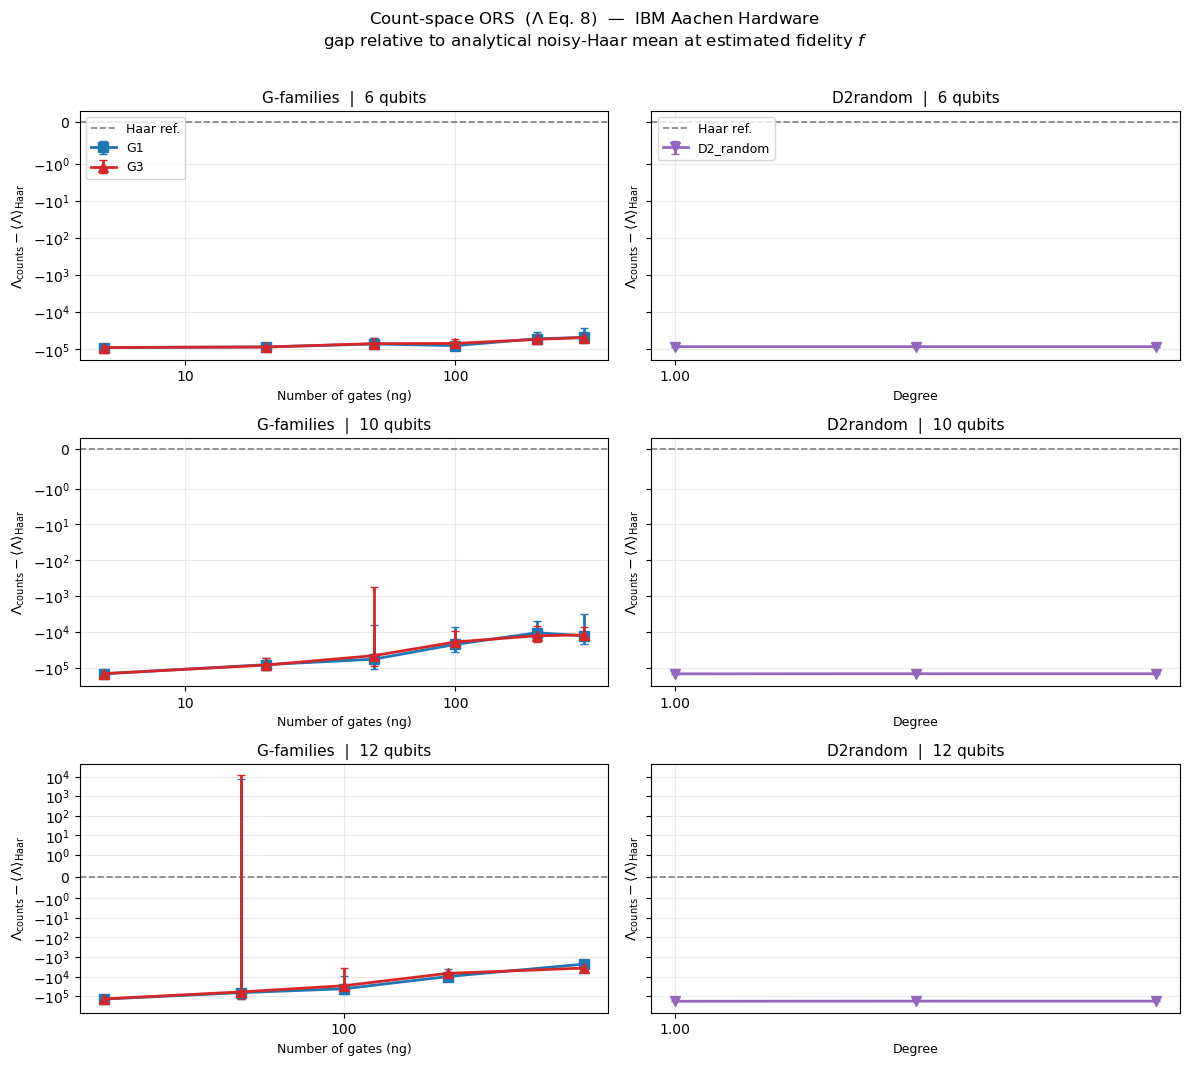

In [118]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

FAMILY_COLORS  = {"G1": "#1f77b4", "G3": "#d62728", "D2_random": "#9467bd"}
FAMILY_MARKERS = {"G1": "s",       "G3": "^",        "D2_random": "v"}


def parse_label(label):
    if "_ng" in label:
        fam, x = label.split("_ng", 1)
        return fam, int(x), "G"
    elif "_deg" in label:
        fam, x = label.rsplit("_deg", 1)
        return fam.replace("D2random", "D2_random"), int(x), "D"
    return None, None, None


def make_ors_plot(score_key, std_key, ref_key, ylabel, title,
                  yscale="linear", linthresh=1):
    """Generic 3-row x 2-col ORS plot. Returns the figure.

    Parameters
    ----------
    yscale : 'linear' | 'symlog'
        Y-axis scale. Use 'symlog' when the gap spans many orders of magnitude.
    linthresh : float
        Only used when yscale='symlog'. Values in (-linthresh, +linthresh) are
        displayed on a linear scale; outside that band, a log scale is used.
    """
    qubit_sizes = [6, 10, 12]
    fig, axes = plt.subplots(
        len(qubit_sizes), 2,
        figsize=(12, 3.5 * len(qubit_sizes)),
        sharey="row",
    )
    fig.subplots_adjust(hspace=0.45, wspace=0.25)

    for row, n_qubits in enumerate(qubit_sizes):
        ax_g = axes[row, 0]
        ax_d = axes[row, 1]

        g_data, d_data = {}, {}
        for label, r in sorted(hw_results[n_qubits].items()):
            fam, x, grp = parse_label(label)
            if fam is None:
                continue
            gap = r[score_key] - r[ref_key]
            err = r[std_key]
            if not np.isfinite(gap):   # skip NaN / inf
                continue
            (g_data if grp == "G" else d_data).setdefault(fam, []).append((x, gap, err))

        for ax, data, xlabel, title_ax in [
            (ax_g, g_data, "Number of gates (ng)", f"G-families  |  {n_qubits} qubits"),
            (ax_d, d_data, "Degree",               f"D2random  |  {n_qubits} qubits"),
        ]:
            for fam, pts in sorted(data.items()):
                pts.sort()
                xs, gaps, errs = zip(*pts)
                col = FAMILY_COLORS.get(fam, "gray")
                mrk = FAMILY_MARKERS.get(fam, "o")
                lbl = fam if row == 0 else None
                ax.errorbar(xs, gaps, yerr=errs, label=lbl, color=col, marker=mrk,
                            linewidth=2, markersize=7, capsize=3, zorder=3)

            ax.axhline(0, color="gray", linestyle="--", linewidth=1.2,
                       label="Haar ref." if row == 0 else None)
            ax.set_xscale("log")
            if yscale == "symlog":
                ax.set_yscale("symlog", linthresh=linthresh)
                ax.yaxis.set_minor_locator(mticker.NullLocator())
            ax.set_ylabel(ylabel, fontsize=10)
            ax.set_xlabel(xlabel, fontsize=9)
            ax.set_title(title_ax, fontsize=11)
            ax.grid(True, which="both", alpha=0.25)
            ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
            ax.xaxis.set_minor_locator(mticker.NullLocator())
            if row == 0:
                ax.legend(fontsize=9, loc="upper left")

    fig.suptitle(title, fontsize=12, y=1.01)
    plt.tight_layout()
    return fig


# ── Plot 1: count-space score (Eq. 8) ────────────────────────────────────────
fig1 = make_ors_plot(
    score_key = "counts_mean",
    std_key   = "counts_std",
    ref_key   = "mean_haar",
    yscale = "symlog",
    ylabel    = r"$\Lambda_{\rm counts} - \langle\Lambda\rangle_{\rm Haar}$",
    title     = (
        "Count-space ORS  ($\\Lambda$ Eq. 8)  —  IBM Aachen Hardware\n"
        "gap relative to analytical noisy-Haar mean at estimated fidelity $f$"
    ),
)
plt.show()

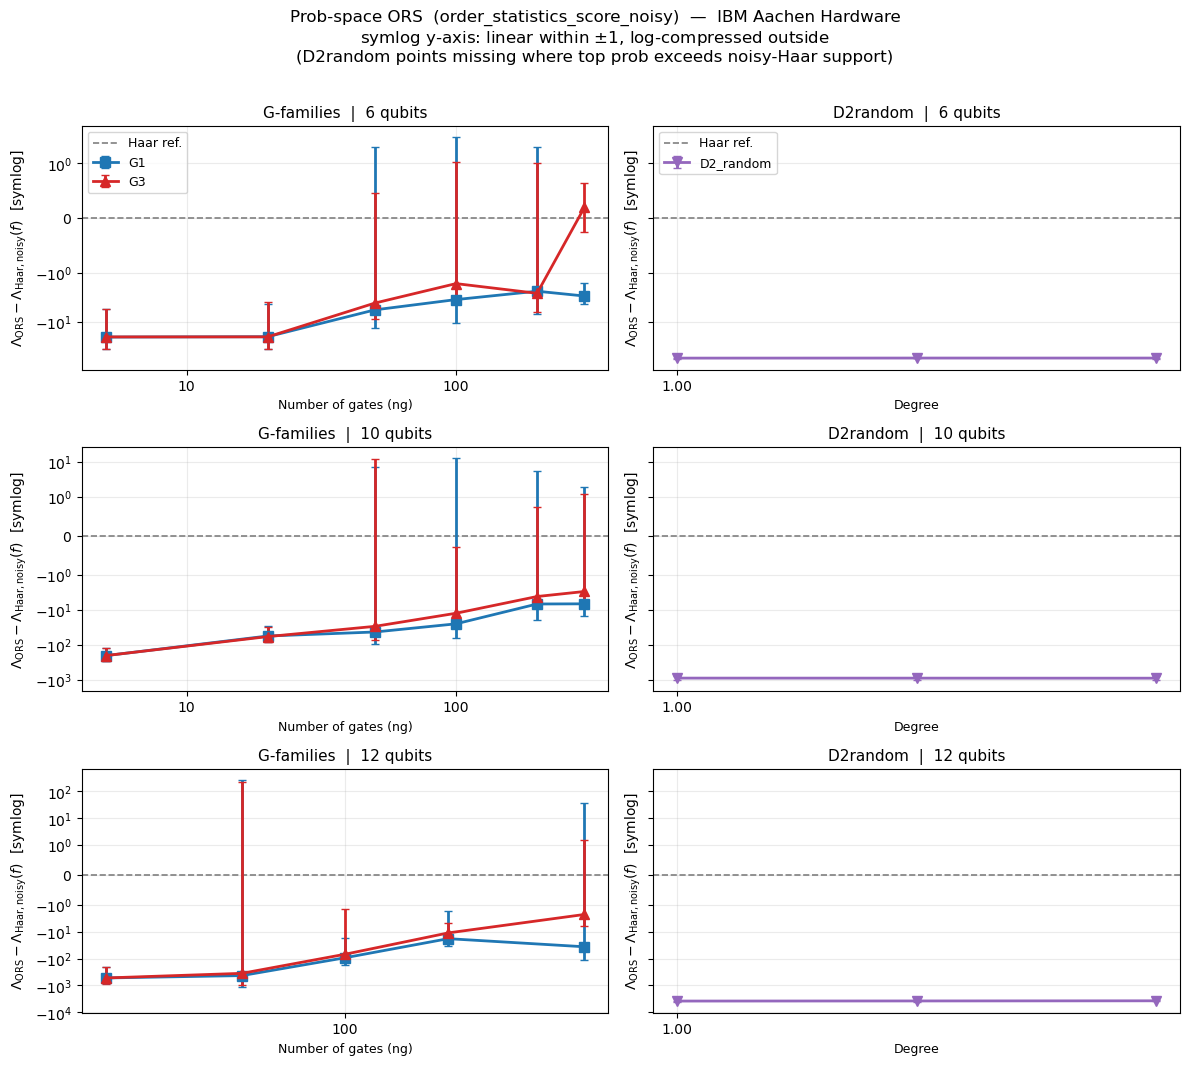

In [119]:
# ── Plot 2: probability-space ORS (order_statistics_score_noisy) ─────────────
# Symlog y-axis (linthresh=1): values in (-1, 0) are linear; outside that band
# each decade is equally spaced, revealing the G1 vs G3 separation that is
# invisible on a linear scale (gap spans ~4 orders of magnitude).
# NaN entries (D2random blocks whose top prob exceeds the noisy-Haar support)
# are silently skipped.
fig2 = make_ors_plot(
    score_key = "ors_mean",
    std_key   = "ors_std",
    ref_key   = "lam_haar",
    ylabel    = r"$\Lambda_{\rm ORS} - \Lambda_{\rm Haar,noisy}(f)$  [symlog]",
    title     = (
        "Prob-space ORS  (order_statistics_score_noisy)  —  IBM Aachen Hardware\n"
        "symlog y-axis: linear within $\\pm$1, log-compressed outside\n"
        "(D2random points missing where top prob exceeds noisy-Haar support)"
    ),
    yscale    = "symlog",
    linthresh = 1,
)
plt.show()

## Results Table: G1 vs G3 ORS Gaps

Tabulated ORS gaps at selected gate counts (50, 300, 500) and all degrees for D2_random. Key observations:
- G3 at ≥200 gates approaches the noisy Haar baseline (gap ≈ 0) across all \(n\).
- G1 remains well below Haar even at 300+ gates, confirming the Clifford barrier.
- D2_random is far below Haar at all degrees and qubit sizes due to its structured commuting form.

In [120]:
# Comparison table
rows = []
# Show only desired number of gates
num_gate_list = [50, 300, 500]
for n_qubits, family_dict in sorted(hw_results.items()):
    for label, r in sorted(family_dict.items()):
        if "_ng" in label:
            fam, x = label.split("_ng", 1)
            ctype, cval = "ng", int(x)
            if cval not in num_gate_list:
                continue
        elif "_deg" in label:
            fam, x = label.rsplit("_deg", 1)
            fam = fam.replace("D2random", "D2_random")
            ctype, cval = "degree", int(x)
        else:
            continue
        ors_val = r["ors_mean"]
        rows.append({
            "n_qubits":    n_qubits,
            "family":      fam,
            ctype:         cval,
            "f_mean":      round(r["f_mean"], 3),
            "Lambda_ORS":  round(ors_val, 2) if np.isfinite(ors_val) else "n/a",
            "Lambda_Haar": round(r["lam_haar"], 2),
            "gap (ORS)":   round(ors_val - r["lam_haar"], 2) if np.isfinite(ors_val) else "n/a",
           # "Lambda_Counts_ORS":     round(r["counts_mean"], 2),
           # "Lambda_Haar_Counts":  round(r['mean_haar'], 2),
           # "gap (ORS Counts)":   round(r["counts_mean"] - r['mean_haar'], 2) if np.isfinite(ors_val) else "n/a",
        })

df_g = pd.DataFrame([r for r in rows if "ng"     in r]).sort_values(["n_qubits", "family", "ng"])
df_d = pd.DataFrame([r for r in rows if "degree" in r]).sort_values(["n_qubits", "family", "degree"])

cols_g = ["n_qubits", "family", "ng",     "f_mean", "Lambda_ORS", "Lambda_Haar", "gap (ORS)",]# "Lambda_Counts_ORS", "Lambda_Haar_Counts", "gap (ORS Counts)"]
cols_d = ["n_qubits", "family", "degree", "f_mean", "Lambda_ORS", "Lambda_Haar", "gap (ORS)", ]#"Lambda_Counts_ORS", "Lambda_Haar_Counts", "gap (ORS Counts)"]

print("=== G1 / G3 families  (z_score uses count-space Lambda) ===")
display(df_g[cols_g])
print("\n=== D2random families  (Lambda_ORS = n/a when top prob exceeds noisy-Haar support) ===")
display(df_d[cols_d])

=== G1 / G3 families  (z_score uses count-space Lambda) ===


,n_qubits,family,ng,f_mean,Lambda_ORS,Lambda_Haar,gap (ORS)
1,6,G1,50,0.933,-3.08,2.63,-5.71
0,6,G1,300,0.935,-0.36,2.63,-2.99
3,6,G3,50,0.938,-1.53,2.62,-4.15
2,6,G3,300,0.939,2.82,2.62,0.19
5,10,G1,50,0.879,-37.89,5.48,-43.37
4,10,G1,300,0.890,-1.36,5.47,-6.83
7,10,G3,50,0.891,-24.47,5.47,-29.94
6,10,G3,300,0.895,2.43,5.46,-3.04
8,12,G1,50,0.863,-424.92,6.89,-431.80
9,12,G1,500,0.855,-29.61,6.90,-36.51



=== D2random families  (Lambda_ORS = n/a when top prob exceeds noisy-Haar support) ===


,n_qubits,family,degree,f_mean,Lambda_ORS,Lambda_Haar,gap (ORS)
0,6,D2_random,1,0.940,-51.94,2.62,-54.56
1,6,D2_random,2,0.940,-51.76,2.62,-54.38
2,6,D2_random,4,0.939,-51.79,2.62,-54.41
3,10,D2_random,1,0.897,-889.03,5.46,-894.49
4,10,D2_random,2,0.897,-891.09,5.46,-896.55
5,10,D2_random,4,0.897,-893.66,5.46,-899.12
6,12,D2_random,1,0.881,-3824.09,6.87,-3830.95
7,12,D2_random,2,0.880,-3788.04,6.87,-3794.90
8,12,D2_random,4,0.876,-3743.30,6.87,-3750.17


## QELM with Quantum Hardware — LiH Excited States

Using the IBM Aachen circuits, we run a **Quantum Extreme Learning Machine (QELM)** for molecular property prediction.

**Task**: predict the first two excited-state energy gaps (\(E_1 - E_0\) and \(E_2 - E_0\)) of LiH at 100 bond lengths from the ground-state wavefunction.

**Protocol**:
1. Load 100 LiH ground states and encode into 10-qubit blocks via amplitude encoding (Ry rotations).
2. Apply G3 reservoir circuit (1000 gates) via `QuantumCircQiskit`.
3. Measure observables via simulation (Pauli encoding) and train a Ridge regressor.
4. Evaluate MSE and scatter-plot predicted vs exact excited-state energies.

### Load LiH Molecular Dataset

The LiH dataset contains pre-computed quantum chemistry results at 100 bond lengths (Jordan-Wigner encoding, active space). Each ground state is an 8-qubit wavefunction with \(2^8 = 256\) real-valued amplitudes.

In [3]:
with open('spectrums_LiH.npy', 'rb') as f:
            spectrums = np.load(f)
with open('bond_lengths_LiH.npy', 'rb') as f:
            bond_lengths = np.load(f)
with open('ground_states_LiH.npy', 'rb') as f:
            ground_states = np.load(f)

num_samples = 100
idxs = np.linspace(0, ground_states.shape[0] - 1, num_samples).astype('int')
spectrums, bond_lengths, ground_states = spectrums[idxs], bond_lengths[idxs], ground_states[idxs]
print("Spectrums shape:", spectrums.shape)
print("Bond lengths shape:", bond_lengths.shape)
print("Ground states shape:", ground_states.shape)

Spectrums shape: (100, 5)
Bond lengths shape: (100,)
Ground states shape: (100, 256)


### Run QELM Circuit on All Ground States

For each of the 100 LiH ground states, the amplitude encoding followed by the reservoir circuit is run with `nshots=40000`. The resulting observable expectations (Pauli-1 and Pauli-2 strings) form the feature matrix for the Ridge regressor.

In [8]:
from QELM import QuantumCircQiskit
from tqdm import tqdm

# Run circuit for all values of ground states:
gate_set = 'G3'
num_gates = 1000
nshots = 40000
nqbits = 10
threshold = 1e-6
observables_type = [1, 2]
obs_res = []
num_states =ground_states.shape[0]

qrc = QuantumCircQiskit(gate_set, nqbits = nqbits, num_gates=100, n_layers=1, 
                        observables_type = observables_type, nshots=nshots,
                        encoding='pauli', theta_scale=-1, statevector=False)

for i in tqdm(range(num_states)):
    state = ground_states[i]
    mask = np.abs(state) > threshold
    amplitudes  = 2*np.asin(state[mask])
    res = qrc.run_circuit(amplitudes)
    obs_res.append(res)
obs_res = np.array(obs_res)    


100%|██████████| 100/100 [19:44<00:00, 11.84s/it]


### Ridge Regression Readout and MSE Evaluation

A Ridge regressor (\(\alpha = 10^{-3}\)) is trained on a 67/33 train/test split to predict the two excited-state energy gaps. Predictions are inverse-scaled and evaluated with MSE. The scatter plot shows predicted vs exact values at test bond lengths.

Mean Squared Error:  0.00018494438655698812


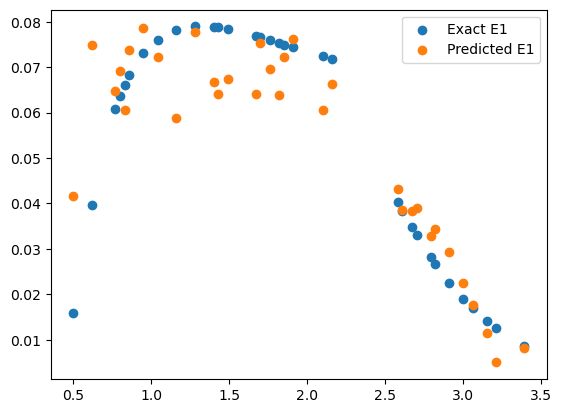

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

num_states =ground_states.shape[0]
y = np.zeros((num_states, 2))
y[:,0] = spectrums[:,1] - spectrums[:,0]
y[:,1] = spectrums[:,2] - spectrums[:,0]


X_train, X_test, y_train, y_test, bond_lengths_train, bond_lengths_test = train_test_split( 
obs_res, y, bond_lengths, test_size=0.33, random_state=42)

scaler = MinMaxScaler()
y_train_scaled = scaler.fit_transform(y_train)
y_test_scaled = scaler.transform(y_test)

lm = Ridge(alpha=1e-3)
lm.fit(X_train, y_train_scaled)

y_hat = lm.predict(X_test)
y_hat = scaler.inverse_transform(y_hat)

mse = np.mean(np.square(y_hat - y_test))
print('Mean Squared Error: ', mse)

plt.scatter(bond_lengths_test,y_test[:,0], label='Exact E1', marker='o')
plt.scatter(bond_lengths_test, y_hat[:,0], label='Predicted E1', marker='o')
plt.legend()
plt.show()